Figure XX - iPSCs PuroR Conventional Cassette

WT iPS11s were infected at low MOI. After the first passage they were flowed to determined the GFP%.

For each biorep one 6-well of iPS11s and one 6-well of transduced iPSCs were dissociated, counted, mixed at given ratios and reseeded at 100k onto 24-wells. THe following 2 days media was changed with 1 ug/mL of puromycin. 3 days post seeding conditions were flowed.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rushd as rd
import scipy as sp
import seaborn as sns

Loading data

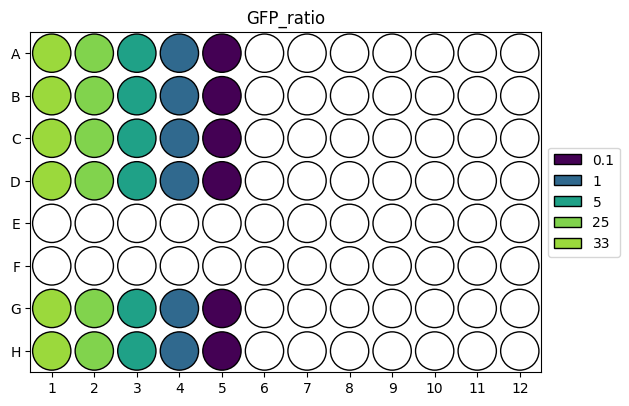

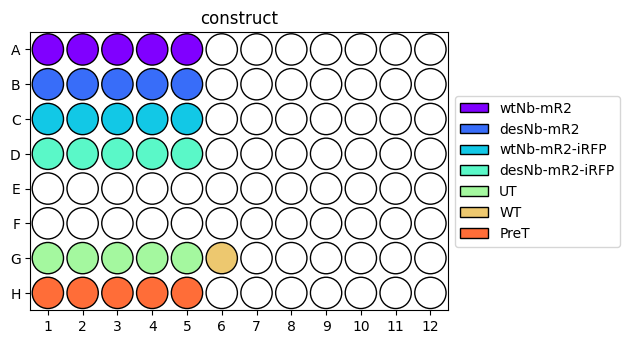

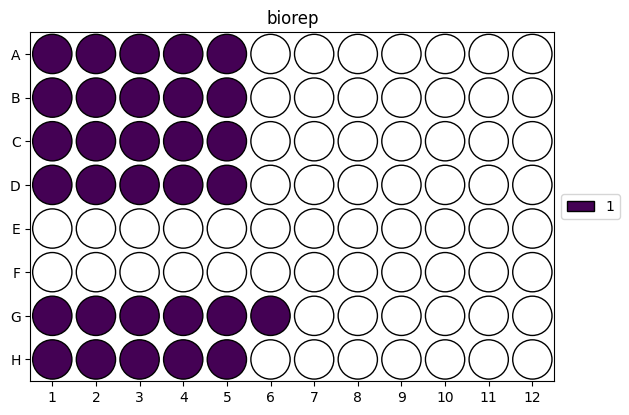

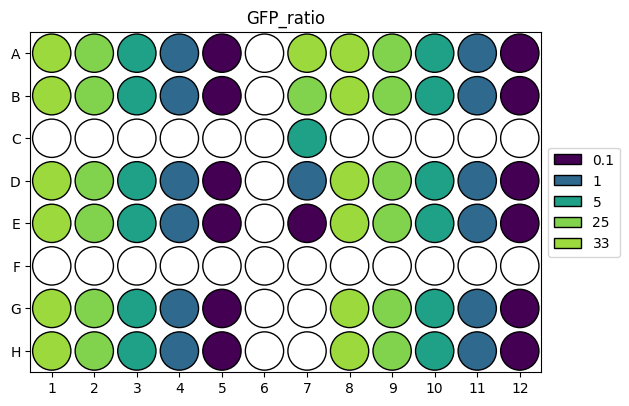

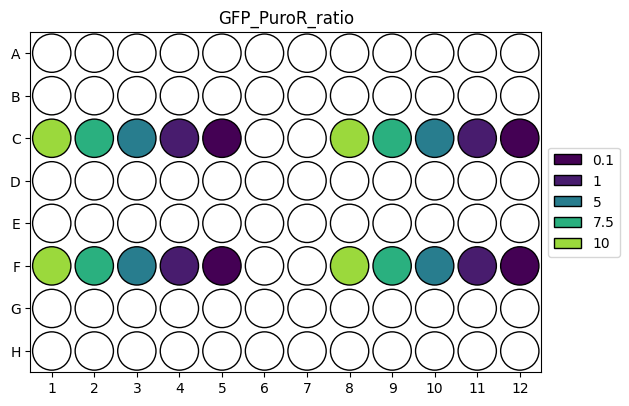

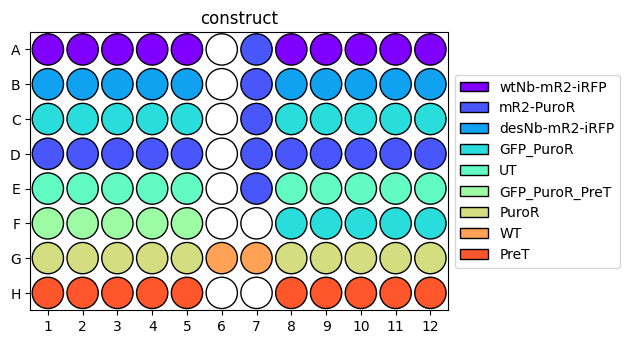

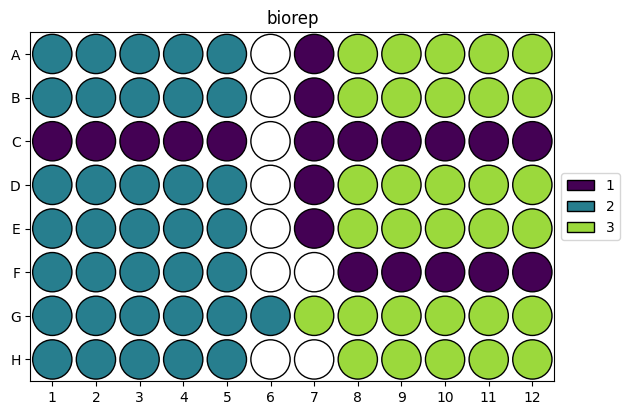

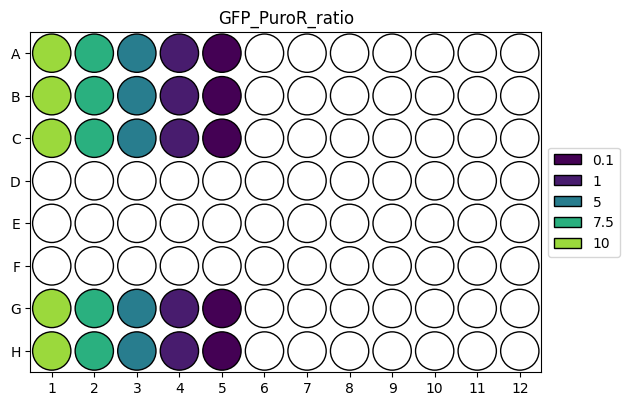

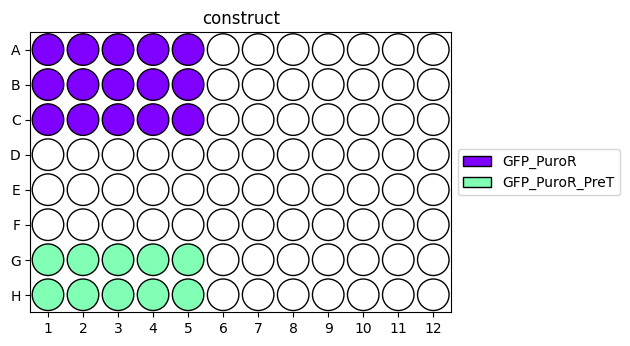

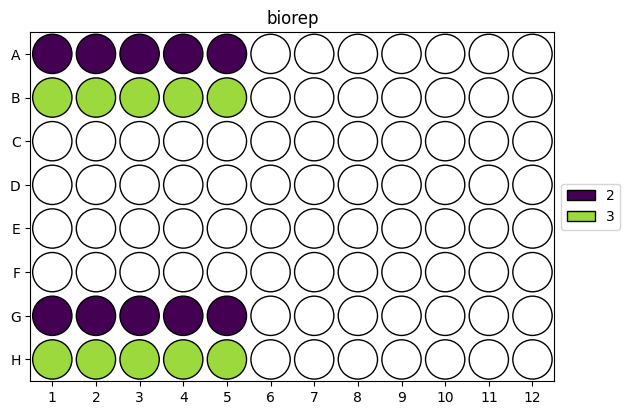

In [2]:
base_path = rd.datadir/'data'/'attune'/'Derin'
plates = pd.DataFrame({'data_path': ['2026.5.22_iPS11_DASIT_modRNA_selection_Biorep1/CSV','2026.6.11_iPS11_DASIT_modRNA_selection_Biorep4&5/CSV', '2026.7.06_iPS11_EGFP-PuroR_dilution_Biorep2&3/CSV'], 
                       'yaml_path': ['2026.5.22_iPS11_DASIT_modRNA_selection_Biorep1/CSV/wells_metadata.yaml','2026.6.11_iPS11_DASIT_modRNA_selection_Biorep4&5/CSV/wells_metadata.yaml', '2026.7.06_iPS11_EGFP-PuroR_dilution_Biorep2&3/CSV/wells_metadata.yaml'],
                       'plate':range(1,4)})
output_path = rd.rootdir/'output'/'Figure_S7_lenti'

for p in plates['yaml_path'].unique():
    rd.plot.plot_well_metadata(base_path/p)

In [3]:
data = pd.DataFrame()
channel_list = ['SSC-A', 'FSC-A', 'EGFP-A'] # for loading with rushd purposes

cache_path = output_path/'data_try2.gzip'

if cache_path.exists():
    data = rd.flow.load_groups_with_metadata(plates, base_path, columns=channel_list)
else:
    data = rd.flow.load_groups_with_metadata(plates, base_path, columns=channel_list)
    data.to_parquet(rd.outfile(cache_path))

data = data[data.construct.isin(['GFP_PuroR', 'GFP_PuroR_PreT', 'WT'])]

data["selection"] = data["construct"].map({
    "GFP_PuroR_PreT": "Pre-Puro",
    "GFP_PuroR": "Post-Puro",
    "WT": "WT"
})

display(data)

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\rushd\flow.py:166: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(data_list, ignore_index=True).replace(np.NaN, pd.NA)  # type: ignore
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\rushd\flow.py:166: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat(data_list, ignore_index=True).replace(np.NaN, pd.NA)  # type: ignore
c:\Users\chemegrad202\AppData\Local\Pr

,GFP_ratio,construct,biorep,well,population,FSC-A,SSC-A,EGFP-A,plate,GFP_PuroR_ratio,selection
2143207,<NA>,WT,1,G6,Single Cells,427494,364494,148.0,1,<NA>,WT
2143208,<NA>,WT,1,G6,Single Cells,411985,189180,107.0,1,<NA>,WT
2143209,<NA>,WT,1,G6,Single Cells,380285,192418,20.0,1,<NA>,WT
2143210,<NA>,WT,1,G6,Single Cells,345297,197564,-69.0,1,<NA>,WT
2143211,<NA>,WT,1,G6,Single Cells,293551,253208,57.0,1,<NA>,WT
...,...,...,...,...,...,...,...,...,...,...,...
15458702,<NA>,GFP_PuroR_PreT,3,H5,Single Cells,353200,145833,29.0,3,0.1,Pre-Puro
15458703,<NA>,GFP_PuroR_PreT,3,H5,Single Cells,246567,209488,157.0,3,0.1,Pre-Puro
15458704,<NA>,GFP_PuroR_PreT,3,H5,Single Cells,453366,249552,-24.0,3,0.1,Pre-Puro
15458705,<NA>,GFP_PuroR_PreT,3,H5,Single Cells,427108,219576,95.0,3,0.1,Pre-Puro


In [4]:
# PUll out the data that has biorep metadata assigned for plotting
plot_data = data.loc[data["biorep"].notna()].copy()

#Define the GFP gate based on the 99.9 percentil of the WT population
EGFP = "EGFP-A"
EGFP_gate = plot_data.loc[plot_data["construct"] == "WT", EGFP].quantile(0.999)

print(f"EGFP gate: {EGFP_gate:.2f}")

#Assign for each cell whether it is GFP+/-
plot_data["GFP_positive"] = plot_data[EGFP] > EGFP_gate

EGFP gate: 432.00


In [10]:
plot_data

,GFP_ratio,construct,biorep,well,population,FSC-A,SSC-A,EGFP-A,plate,GFP_PuroR_ratio,selection,GFP_positive
2143207,<NA>,WT,1,G6,Single Cells,427494,364494,148.0,1,<NA>,WT,False
2143208,<NA>,WT,1,G6,Single Cells,411985,189180,107.0,1,<NA>,WT,False
2143209,<NA>,WT,1,G6,Single Cells,380285,192418,20.0,1,<NA>,WT,False
2143210,<NA>,WT,1,G6,Single Cells,345297,197564,-69.0,1,<NA>,WT,False
2143211,<NA>,WT,1,G6,Single Cells,293551,253208,57.0,1,<NA>,WT,False
...,...,...,...,...,...,...,...,...,...,...,...,...
15458702,<NA>,GFP_PuroR_PreT,3,H5,Single Cells,353200,145833,29.0,3,0.1,Pre-Puro,False
15458703,<NA>,GFP_PuroR_PreT,3,H5,Single Cells,246567,209488,157.0,3,0.1,Pre-Puro,False
15458704,<NA>,GFP_PuroR_PreT,3,H5,Single Cells,453366,249552,-24.0,3,0.1,Pre-Puro,False
15458705,<NA>,GFP_PuroR_PreT,3,H5,Single Cells,427108,219576,95.0,3,0.1,Pre-Puro,False


Generate summary table with total cell count, GFP+ cell count, and GFP+ %

In [12]:
nonWT_data = plot_data.loc[plot_data["selection"].isin(["Pre-Puro", "Post-Puro"])].copy()

summary = (nonWT_data.groupby(["biorep", "GFP_PuroR_ratio", "selection"],observed=True).agg(
        total_cell_count=(EGFP, "size"),
        GFP_positive_count=("GFP_positive", "sum")
    ).reset_index())

summary["percent_GFP_positive"] = (summary["GFP_positive_count"]/ summary["total_cell_count"]* 100)

display(summary)

,biorep,GFP_PuroR_ratio,selection,total_cell_count,GFP_positive_count,percent_GFP_positive
0,1,0.1,Post-Puro,115296,102864,89.217319
1,1,1.0,Post-Puro,646671,582648,90.099602
2,1,5.0,Post-Puro,244564,232095,94.901539
3,1,7.5,Post-Puro,323213,299453,92.648811
4,1,10.0,Post-Puro,436240,391103,89.653173
5,2,0.1,Post-Puro,9424,8975,95.235569
6,2,0.1,Pre-Puro,88121,125,0.141850
7,2,1.0,Post-Puro,20074,18738,93.344625
8,2,1.0,Pre-Puro,71516,667,0.932658
9,2,5.0,Post-Puro,17122,16255,94.936339


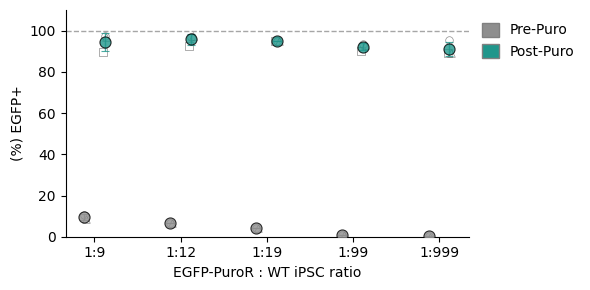

In [6]:
from matplotlib.patches import Patch

ratio_order = [10, 7.5, 5, 1, 0.1]
selection_order = ["Pre-Puro", "Post-Puro"]

palette = { "Pre-Puro": "#8E8E8E", "Post-Puro": "#1F968BFF"}

markers = {
    1: "s",
    2: "o",
    3: "^"
}

y = "percent_GFP_positive"

#Biorep mean
bio_means = summary.copy()

# Mean + SD across biological replicates
plot_summary = (bio_means.groupby(["selection", "GFP_PuroR_ratio"],as_index=False, observed=True)
    .agg( mean=(y, "mean"), sd=(y, "std")))

#Barplot with individual bioreps 
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

group_centers = np.arange(len(ratio_order))

# offsets for Pre vs Post
offsets = {
    "Pre-Puro": -0.12,
    "Post-Puro": 0.12
}

# tiny offsets so biological replicate points don't perfectly overlap
rep_offsets = {
    1: -0.02,
    2: 0,
    3: 0.02
}


for rep, marker in markers.items():

    rep_data = bio_means.loc[bio_means["biorep"] == rep]

    for i, ratio in enumerate(ratio_order):

        for selection in selection_order:

            row = rep_data.loc[
                (rep_data["GFP_PuroR_ratio"] == ratio) &
                (rep_data["selection"] == selection)
            ]

            if row.empty:
                continue

            xloc = (
                group_centers[i]
                + offsets[selection]
                + rep_offsets[rep]
            )

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=marker,
                s=30,
                facecolor="white",
                edgecolor="black",
                linewidth=0.5,
                alpha=0.45,
                zorder=2
            )


# ---------------------------------------------------------
# Mean ± SD — front layer
# ---------------------------------------------------------

for i, ratio in enumerate(ratio_order):

    for selection in selection_order:

        row = plot_summary.loc[
            (plot_summary["GFP_PuroR_ratio"] == ratio) &
            (plot_summary["selection"] == selection)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[selection]

        ax.errorbar(
            xloc,
            row["mean"].iloc[0],
            yerr=row["sd"].iloc[0],
            fmt="o",
            markersize=8,
            color=palette[selection],
            alpha=0.8,
            mec="black",
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )


# Formatting

ax.set_ylabel("(%) EGFP+")
ax.set_xlabel("EGFP-PuroR : WT iPSC ratio")

ax.set_ylim(0, 110)

ax.set_xticks(group_centers)
ax.set_xticklabels([
    "1:9",
    "1:12",
    "1:19",
    "1:99",
    "1:999"
])

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f"{x:.0f}"
    )
)

sns.despine()

# Legend

legend_handles = [
    Patch(
        facecolor=palette["Pre-Puro"],
        edgecolor="grey",
        label="Pre-Puro"
    ),
    Patch(
        facecolor=palette["Post-Puro"],
        edgecolor="grey",
        label="Post-Puro"
    )
]

ax.legend(
    handles=legend_handles,
    title="",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)


# Optional 100% reference line
ax.axhline(
    100,
    color="grey",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

fig.tight_layout()
plt.show()

1_Pre-Puro vs. 1_Post-Puro: ***
5_Pre-Puro vs. 5_Post-Puro: ****
0.1_Pre-Puro vs. 0.1_Post-Puro: ***


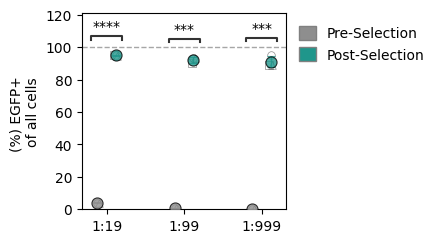

In [7]:
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
from statannotations.Annotator import Annotator

ratio_order = [5, 1, 0.1]
selection_order = ["Pre-Puro", "Post-Puro"]

x = "GFP_PuroR_ratio"
y = "percent_GFP_positive"
hue = "selection"

palette = {
    "Pre-Puro": "#8E8E8E",
    "Post-Puro": "#1F968BFF"
}

markers = {
    1: "s",
    2: "o",
    3: "^"
}


# Calculate plotted values (mean ± SD) across bioreps

bio_means = summary.loc[(summary["selection"].isin(selection_order)) & (summary["GFP_PuroR_ratio"].isin(ratio_order))].copy()

plot_summary = (bio_means.groupby(["selection", "GFP_PuroR_ratio"],as_index=False,observed=True)
    .agg(
        mean=(y, "mean"),
        sd=(y, "std")
    )
)


#Plot scatter plot w/ overlayed mean +SD errorbars 
fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))

group_centers = np.arange(len(ratio_order))

offsets = {
    "Pre-Puro": -0.12,
    "Post-Puro": 0.12
}

rep_offsets = {
    1: -0.02,
    2: 0,
    3: 0.02
}

# ---------------------------------------------------------
# Individual biological replicate points
# ---------------------------------------------------------

for rep, marker in markers.items():

    rep_data = bio_means.loc[bio_means["biorep"] == rep]

    for i, ratio in enumerate(ratio_order):

        for selection in selection_order:

            row = rep_data.loc[
                (rep_data["GFP_PuroR_ratio"] == ratio) &
                (rep_data["selection"] == selection)
            ]

            if row.empty:
                continue

            xloc = (
                group_centers[i]
                + offsets[selection]
                + rep_offsets[rep]
            )

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=marker,
                s=30,
                facecolor="white",
                edgecolor="black",
                linewidth=0.5,
                alpha=0.45,
                zorder=2
            )


# Mean ± SD
for i, ratio in enumerate(ratio_order):

    for selection in selection_order:

        row = plot_summary.loc[
            (plot_summary["GFP_PuroR_ratio"] == ratio) &
            (plot_summary["selection"] == selection)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[selection]

        ax.errorbar(
            xloc,
            row["mean"].iloc[0],
            yerr=row["sd"].iloc[0],
            fmt="o",
            markersize=8,
            color=palette[selection],
            alpha=0.8,
            mec="black",
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )


# Formatting

ax.set_ylabel("(%) EGFP+ \nof all cells")
ax.set_xlabel("")

ax.set_ylim(0, 110)

ax.set_xticks(group_centers)
ax.set_xticklabels([
    "1:19",
    "1:99",
    "1:999"
])

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f"{x:.0f}"
    )
)



# Legend
legend_handles = [
    Patch(
        facecolor=palette["Pre-Puro"],
        edgecolor="grey",
        label="Pre-Selection"
    ),
    Patch(
        facecolor=palette["Post-Puro"],
        edgecolor="grey",
        label="Post-Selection"
    )
]

ax.legend(
    handles=legend_handles,
    title="",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

ax.axhline(
    100,
    color="grey",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


# Statistical tests: Pre-Puro vs Post-Puro at each ratio

pairs = [
    ((ratio, "Pre-Puro"), (ratio, "Post-Puro"))
    for ratio in ratio_order
]

annotations = []

for ratio in ratio_order:

    vals_pre = bio_means.loc[
        (bio_means["GFP_PuroR_ratio"] == ratio) &
        (bio_means["selection"] == "Pre-Puro"),
        y
    ]

    vals_post = bio_means.loc[
        (bio_means["GFP_PuroR_ratio"] == ratio) &
        (bio_means["selection"] == "Post-Puro"),
        y
    ]

    _, p = ttest_ind(
        vals_pre,
        vals_post,
        equal_var=False
    )

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    annotations.append(stars)


# Add statistical annotations
annotator = Annotator(
    ax,
    pairs=pairs,
    data=bio_means,
    x=x,
    y=y,
    hue=hue,
    order=ratio_order,
    hue_order=selection_order
)

annotator.configure(
    text_format="full",
    loc="inside",
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()

fig.tight_layout()

plottitle = "Figure_XX_iPSCs_controls_puroR_purity_lenti.svg"

plt.savefig(
    rd.outfile(output_path / plottitle),
    bbox_inches="tight"
)

plt.show()

In [15]:
data_wt = pd.DataFrame()
output_path3 = rd.rootdir/'output'/'Figure_XX_iPSCs'
cache_path3 = output_path3/'data_iPSC_wt_percents.gzip'
if cache_path3.is_file(): data_wt = pd.read_parquet(cache_path3)

In [20]:
df = summary.copy()
# Rename selection -> condition
df = df.rename(columns={'selection': 'construct'})

# Change GFP_PuroR_ratio values and rename column -> ratio
df['GFP_PuroR_ratio'] = df['GFP_PuroR_ratio'].replace({
    5.0: '1:19',
    7.5: '1:99',
    10.0: '1:999'
})
df = df.rename(columns={'GFP_PuroR_ratio': 'ratio'})

# Remove GFP_positive_count
df = df.drop(columns='GFP_positive_count')

# Rename remaining columns
df = df.rename(columns={
    'percent_GFP_positive': 'percent',
    'total_cell_count': 'cell_count'
})

# Combine with data_wt
data_combined = pd.concat([df, data_wt], ignore_index=True)

In [21]:
display(data_combined)

,biorep,ratio,construct,cell_count,percent
0,1,0.1,Post-Puro,115296,89.217319
1,1,1.0,Post-Puro,646671,90.099602
2,1,1:19,Post-Puro,244564,94.901539
3,1,1:99,Post-Puro,323213,92.648811
4,1,1:999,Post-Puro,436240,89.653173
...,...,...,...,...,...
115,2,1:99,wtNb-mR2-iRFP,19921,1.395512
116,3,1:99,wtNb-mR2-iRFP,96931,2.270687
117,1,1:999,wtNb-mR2-iRFP,131765,0.084241
118,2,1:999,wtNb-mR2-iRFP,182700,0.302682


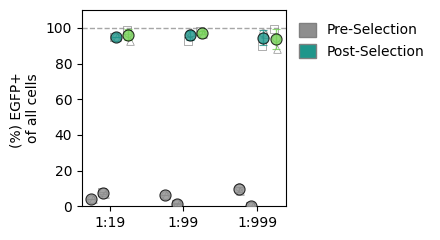

In [ ]:
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
from statannotations.Annotator import Annotator

ratio_order =  ['1:19', '1:99', '1:999']
selection_order = ["Pre-Puro",'PreT', "Post-Puro", 'desNb-mR2-iRFP']

x = "ratio"
y = "percent"
hue = "construct"

palette = {
    "Pre-Puro": "#8E8E8E",
    "Post-Puro": "#1F968BFF",
    'PreT':'#8E8E8E',
    'desNb-mR2-iRFP':"#73D055FF"
}

markers = {
    1: "s",
    2: "o",
    3: "^"
}


# Calculate plotted values (mean ± SD) across bioreps

bio_means = data_combined.loc[(data_combined["construct"].isin(selection_order)) & (data_combined["ratio"].isin(ratio_order))].copy()

plot_summary = (bio_means.groupby(["construct", "ratio"],as_index=False,observed=True)
    .agg(
        mean=(y, "mean"),
        sd=(y, "std")
    )
)


#Plot scatter plot w/ overlayed mean +SD errorbars 
fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))

group_centers = np.arange(len(ratio_order))
offsets = np.linspace(-0.25, 0.25, len(selection_order))

rep_offsets = {
    1: -0.02,
    2: 0,
    3: 0.02
}

# ---------------------------------------------------------
# Individual biological replicate points
# ---------------------------------------------------------

for rep, marker in markers.items():

    rep_data = bio_means.loc[bio_means["biorep"] == rep]

    for i, ratio in enumerate(ratio_order):

        for j, selection in enumerate(selection_order):

            row = rep_data.loc[
                (rep_data["ratio"] == ratio) &
                (rep_data["construct"] == selection)
            ]

            if row.empty:
                continue

            xloc = (
                group_centers[i]
                + offsets[j]
                + rep_offsets[rep]
            )

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=marker,
                s=30,
                facecolor="white",
                edgecolor="black",
                linewidth=0.5,
                alpha=0.45,
                zorder=2
            )


# Mean ± SD
for i, ratio in enumerate(ratio_order):

    for j, selection in enumerate(selection_order):

        row = plot_summary.loc[
            (plot_summary["ratio"] == ratio) &
            (plot_summary["construct"] == selection)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row["mean"].iloc[0],
            yerr=row["sd"].iloc[0],
            fmt="o",
            markersize=8,
            color=palette[selection],
            alpha=0.8,
            mec="black",
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )


# Formatting

ax.set_ylabel("(%) EGFP+ \nof all cells")
ax.set_xlabel("")

ax.set_ylim(0, 110)

ax.set_xticks(group_centers)
ax.set_xticklabels([
    "1:19",
    "1:99",
    "1:999"
])

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f"{x:.0f}"
    )
)

label_map = {'PreT':'Pre-DASIT', 
            'Post-Puro':'Lenti Post Selection', 
            'Pre-Puro':'Lenti Pre Selection',
             'desNb-mR2-iRFP':'desNb'}

# Legend
legend_handles = [
    Patch(
        facecolor=palette["Pre-Puro"],
        edgecolor="grey",
        label="Pre-Selection"
    ),
    Patch(
        facecolor=palette["Post-Puro"],
        edgecolor="grey",
        label="Post-Selection"
    )
]

ax.legend(
    handles=legend_handles,
    title="",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

ax.axhline(
    100,
    color="grey",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


fig.tight_layout()

plottitle = "Figure_XX_iPSCs_controls_puroR_purity_lenti.svg"

plt.savefig(
    rd.outfile(output_path / plottitle),
    bbox_inches="tight"
)

plt.show()

   ratio                   comparison       t_stat       p_value
0   1:19        Pre-Puro vs Post-Puro -1340.090416  9.163631e-10
1   1:19  Post-Puro vs desNb-mR2-iRFP    -0.714885  5.141860e-01
2   1:99        Pre-Puro vs Post-Puro   -44.405224  2.514063e-05
3   1:99  Post-Puro vs desNb-mR2-iRFP    -0.909968  4.143127e-01
4  1:999        Pre-Puro vs Post-Puro   -26.143510  1.227711e-04
5  1:999  Post-Puro vs desNb-mR2-iRFP     0.193658  8.558802e-01


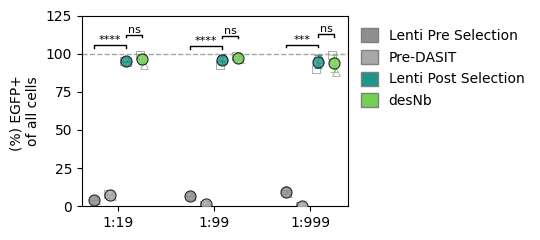

In [35]:
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

ratio_order = ['1:19', '1:99', '1:999']
selection_order = ["Pre-Puro", 'PreT', "Post-Puro", 'desNb-mR2-iRFP']

x = "ratio"
y = "percent"
hue = "construct"

# ---------------------------------------------------------
# Colors
# ---------------------------------------------------------

palette = {
    "Pre-Puro": "#8E8E8E",
    "PreT": "#A8A8A8",                 # slightly different grey
    "Post-Puro": "#1F968BFF",
    "desNb-mR2-iRFP": "#73D055FF"
}

markers = {
    1: "s",
    2: "o",
    3: "^"
}

# Labels for legend
label_map = {
    'PreT': 'Pre-DASIT',
    'Post-Puro': 'Lenti Post Selection',
    'Pre-Puro': 'Lenti Pre Selection',
    'desNb-mR2-iRFP': 'desNb'
}


# ---------------------------------------------------------
# Calculate plotted values (mean ± SD) across bioreps
# ---------------------------------------------------------

bio_means = data_combined.loc[
    (data_combined["construct"].isin(selection_order)) &
    (data_combined["ratio"].isin(ratio_order))
].copy()

plot_summary = (
    bio_means
    .groupby(
        ["construct", "ratio"],
        as_index=False,
        observed=True
    )
    .agg(
        mean=(y, "mean"),
        sd=(y, "std")
    )
)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=(5.5, 2.5))

group_centers = np.arange(len(ratio_order))
offsets = np.linspace(-0.25, 0.25, len(selection_order))

rep_offsets = {
    1: -0.02,
    2: 0,
    3: 0.02
}


# ---------------------------------------------------------
# Individual biological replicate points
# ---------------------------------------------------------

for rep, marker in markers.items():

    rep_data = bio_means.loc[bio_means["biorep"] == rep]

    for i, ratio in enumerate(ratio_order):

        for j, selection in enumerate(selection_order):

            row = rep_data.loc[
                (rep_data["ratio"] == ratio) &
                (rep_data["construct"] == selection)
            ]

            if row.empty:
                continue

            xloc = (
                group_centers[i]
                + offsets[j]
                + rep_offsets[rep]
            )

            ax.scatter(
                xloc,
                row[y].iloc[0],
                marker=marker,
                s=30,
                facecolor="white",
                edgecolor="black",
                linewidth=0.5,
                alpha=0.45,
                zorder=2
            )


# ---------------------------------------------------------
# Mean ± SD
# ---------------------------------------------------------

for i, ratio in enumerate(ratio_order):

    for j, selection in enumerate(selection_order):

        row = plot_summary.loc[
            (plot_summary["ratio"] == ratio) &
            (plot_summary["construct"] == selection)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row["mean"].iloc[0],
            yerr=row["sd"].iloc[0],
            fmt="o",
            markersize=8,
            color=palette[selection],
            alpha=0.8,
            mec="black",
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )


# ---------------------------------------------------------
# Statistical tests
#
# Pre-Puro vs Post-Puro
# Post-Puro vs desNb
# ---------------------------------------------------------

comparison_pairs = [
    ("Pre-Puro", "Post-Puro"),
    ("Post-Puro", "desNb-mR2-iRFP")
]

# Store p-values so they are also easy to inspect
p_values = []

for ratio in ratio_order:

    for cond1, cond2 in comparison_pairs:

        vals1 = bio_means.loc[
            (bio_means["ratio"] == ratio) &
            (bio_means["construct"] == cond1),
            y
        ].dropna()

        vals2 = bio_means.loc[
            (bio_means["ratio"] == ratio) &
            (bio_means["construct"] == cond2),
            y
        ].dropna()

        t_stat, p_val = ttest_ind(
            vals1,
            vals2,
            equal_var=True
        )

        p_values.append({
            "ratio": ratio,
            "comparison": f"{cond1} vs {cond2}",
            "t_stat": t_stat,
            "p_value": p_val
        })

# Optional: print the statistical results
stats_df = pd.DataFrame(p_values)
print(stats_df)


# ---------------------------------------------------------
# Function for significance labels
# ---------------------------------------------------------

def significance_label(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


# ---------------------------------------------------------
# Add significance brackets
# ---------------------------------------------------------

def add_sig_bracket(
    ax,
    x1,
    x2,
    y,
    h,
    text,
    linewidth=1
):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        lw=linewidth,
        c="black",
        clip_on=False
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=8
    )


# Heights of the two comparisons
# Pre-Puro vs Post-Puro is the inner comparison
# Post-Puro vs desNb is the outer comparison

for i, ratio in enumerate(ratio_order):

    # Get p-values
    p_pre_post = stats_df.loc[
        (stats_df["ratio"] == ratio) &
        (stats_df["comparison"] == "Pre-Puro vs Post-Puro"),
        "p_value"
    ].iloc[0]

    p_post_des = stats_df.loc[
        (stats_df["ratio"] == ratio) &
        (stats_df["comparison"] == "Post-Puro vs desNb-mR2-iRFP"),
        "p_value"
    ].iloc[0]

    # x positions
    x_pre = group_centers[i] + offsets[0]
    x_post = group_centers[i] + offsets[2]
    x_des = group_centers[i] + offsets[3]

    # Find the maximum plotted value for this ratio
    ratio_data = bio_means.loc[
        bio_means["ratio"] == ratio,
        y
    ]

    ymax = ratio_data.max()

    # First bracket
    y1 = ymax + 5

    add_sig_bracket(
        ax,
        x_pre,
        x_post,
        y1,
        h=1.5,
        text=significance_label(p_pre_post)
    )

    # Second bracket
    y2 = y1 + 7

    add_sig_bracket(
        ax,
        x_post,
        x_des,
        y2,
        h=1.5,
        text=significance_label(p_post_des)
    )


# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

ax.set_ylabel("(%) EGFP+ \nof all cells")
ax.set_xlabel("")

ax.set_ylim(0, 125)

ax.set_xticks(group_centers)
ax.set_xticklabels([
    "1:19",
    "1:99",
    "1:999"
])

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f"{x:.0f}"
    )
)


# ---------------------------------------------------------
# Legend using label_map
# ---------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=palette[selection],
        edgecolor="grey",
        label=label_map[selection]
    )
    for selection in selection_order
]

ax.legend(
    handles=legend_handles,
    title="",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)


# ---------------------------------------------------------
# 100% reference line
# ---------------------------------------------------------

ax.axhline(
    100,
    color="grey",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


fig.tight_layout()

plottitle = "Figure_XX_iPSCs_controls_puroR_purity_lenti.svg"

plt.savefig(
    rd.outfile(output_path / plottitle),
    bbox_inches="tight"
)

plt.show()